# Set-up

In [1]:
import os
import sys
import csv
import random
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import spearmanr, pearsonr

import hashlib

def create_run_hash(*args):
    hash_object = hashlib.sha256()
    for arg in args:
        hash_object.update(str(arg).encode())
    return hash_object.hexdigest()

import seqpro as sp

from ledidi import ledidi
from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.io import extract_loci
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [3]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [4]:
path_out = "/cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_07_05/day15_ENP_MPRA_design"

# Load genome

In [5]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [6]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [7]:
# Load peaks
path_peaks = "scratch/2025_07_05/day15_ENP_MPRA_design/peaks_with_predictions.tsv"
peaks = pd.read_csv(path_peaks, sep="\t")
peaks = peaks[peaks["log_counts_pred"] >= 0]
peaks.head()

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred
0,chr1,633840,634204,.,1000,.,40.609467,109236.929688,109228.906250,193,11.451295,4.753467
1,chr17,22521248,22521557,.,1000,.,43.419971,34642.917969,34635.835938,150,10.262176,4.971176
2,chr1,629813,630101,.,1000,.,8.402439,10337.239258,10330.491211,142,9.857549,3.479598
3,chr1,16612947,16614053,.,1000,.,25.223841,7114.754395,7108.110352,661,9.432923,8.318419
4,chr17,43251568,43251928,.,1000,.,46.463974,6077.647949,6071.098633,146,8.542471,8.081451


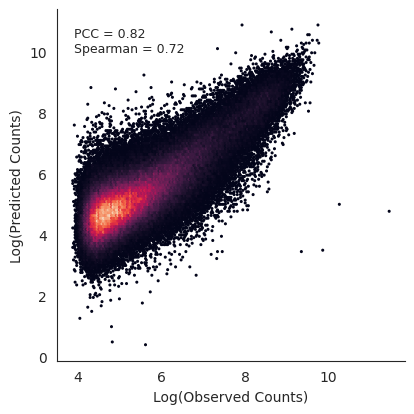

In [8]:
# Set up figure
fig, ax = plt.subplots(1, 1, figsize=(4.25, 4.25))

# Replace KDE with hexbin
ax.hexbin(
    peaks["log_counts"],
    peaks["log_counts_pred"],
    gridsize=200,
    mincnt=1,
    alpha=1
)

# Pearson r and spearman r
pcc_val, pcc_pval = pearsonr(peaks["log_counts_pred"], peaks["log_counts"])
spearman_val, spearman_pval = spearmanr(peaks["log_counts_pred"], peaks["log_counts"])

# Clean up plot
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Log(Observed Counts)")
ax.set_ylabel("Log(Predicted Counts)")

# Top left annotation with stats
ax.text(
    0.05, 0.95,
    f"PCC = {pcc_val:.2f}\nSpearman = {spearman_val:.2f}",
    fontsize=9,
    transform=ax.transAxes,
    ha='left', va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

# 
fig.tight_layout()

# Load motifs

In [9]:
path_motifs = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme"
motifs = read_meme(path_motifs)
motif_names = np.array(list(motifs.keys()))

In [10]:
path_annot = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/tfs_initial.txt"
tmp = pd.read_csv(path_annot, header=None, sep='\t', names=["motif_id", "annotated_tf", "evalue"])
motif_id_mp = tmp.set_index("motif_id")["annotated_tf"]

# Load model

In [11]:
path_model = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()
count_wrapper = CountWrapper(model).cuda().eval()

# Load sequences

In [12]:
# find the peaks that intersect with the isl1 enhancer coordinates
def intersects_with_peak(row, peaks):
    chrom = row['chrom']
    start = row['start']
    end = row['end']
    
    # Filter peaks for the same chromosome
    chrom_peaks = peaks[peaks["chrom"] == chrom]
    
    # Check if any peak overlaps with the enhancer region
    for _, peak in chrom_peaks.iterrows():
        peak_start = peak["start"]
        peak_end = peak["end"]
        if not (end < peak_start or start > peak_end):  # No overlap condition
            return True
    return False

# and add the peak coordinates to the dataframe
def get_peak_coordinates(row, peaks):
    chrom = row['chrom']
    start = row['start']
    end = row['end']
    
    # Filter peaks for the same chromosome
    chrom_peaks = peaks[peaks["chrom"] == chrom]
    
    # Check if any peak overlaps with the enhancer region
    for _, peak in chrom_peaks.iterrows():
        peak_start = peak["start"]
        peak_end = peak["end"]
        if not (end < peak_start or start > peak_end):  # No overlap condition
            return f"{chrom}:{peak_start}-{peak_end}"
    return None

In [13]:
# Read in the headers from each sequence to get the coordinates
path_fasta = "scratch/2025_07_05/day15_ENP_MPRA_design/ISL1_CRE.fa"
seqs = pyfaidx.Fasta(path_fasta)
seq_headers = list(seqs.keys())
isl1_enhancer_df = pd.DataFrame(seq_headers, columns=['header'])
isl1_enhancer_df['chrom'] = isl1_enhancer_df['header'].str.split(':').str[0]
isl1_enhancer_df['start'] = isl1_enhancer_df['header'].str.split(':').str[1].str.split('-').str[0].astype(int)
isl1_enhancer_df['end'] = isl1_enhancer_df['header'].str.split(':').str[1].str.split('-').str[1].astype(int)
isl1_enhancer_df['intersects_peak'] = isl1_enhancer_df.apply(intersects_with_peak, peaks=peaks, axis=1)
isl1_enhancer_df['peak_coordinates'] = isl1_enhancer_df.apply(get_peak_coordinates, peaks=peaks, axis=1)
isl1_enhancer_df["peak_chrom"] = isl1_enhancer_df["peak_coordinates"].str.split(":").str[0]
isl1_enhancer_df["peak_start"] = isl1_enhancer_df["peak_coordinates"].str.split(":").str[1].str.split("-").str[0].astype(int)
isl1_enhancer_df["peak_end"] = isl1_enhancer_df["peak_coordinates"].str.split(":").str[1].str.split("-").str[1].astype(int)
isl1_enhancer_df

,header,chrom,start,end,intersects_peak,peak_coordinates,peak_chrom,peak_start,peak_end
0,chr5:51383447-51385561,chr5,51383447,51385561,True,chr5:51382751-51383709,chr5,51382751,51383709
1,chr5:51392146-51392917,chr5,51392146,51392917,True,chr5:51392398-51392614,chr5,51392398,51392614
2,chr5:51398691-51400017,chr5,51398691,51400017,True,chr5:51398819-51399745,chr5,51398819,51399745


In [14]:
# Annote peaks as Enhancer_1, Enhancer_2, etc.
peaks_selected = peaks.merge(isl1_enhancer_df[["peak_chrom", "peak_start", "peak_end"]], 
                                       left_on=["chrom", "start", "end"], 
                                       right_on=["peak_chrom", "peak_start", "peak_end"], 
                                       how="left", suffixes=("", "_enhancer"))
peaks_selected['CRE_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'Enhancer',
    np.nan
)
peaks_selected['CRE_annotation'] = peaks_selected.groupby('chrom').cumcount() + 1
peaks_selected['CRE_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'CRE_' + peaks_selected['CRE_annotation'].astype(str),
    np.nan
)

# Drop the temporary columns used for annotation
peaks_selected = peaks_selected.drop(columns=["peak_chrom", "peak_start", "peak_end"])
peaks_selected["CRE_annotation"].value_counts()

CRE_719     1
CRE_2023    1
CRE_6290    1
Name: CRE_annotation, dtype: int64

In [15]:
# Get the deciles of the distribution
deciles = np.percentile(peaks_selected["log_counts_pred"].dropna(), [0, 5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 100])
deciles

array([ 0.3704744 ,  3.92168246,  4.34471609,  4.60536172,  4.82451904,
        5.03627367,  5.2626063 ,  5.52310919,  5.86997775,  6.41905241,
        7.63897895, 10.879662  ])

In [16]:
# Which decile bin does each CRE belong to?
peaks_selected['decile'] = pd.cut(peaks_selected['log_counts_pred'], bins=deciles, labels=False)
peaks_selected["decile"].value_counts()

3.0     23371
4.0     23371
9.0     23371
8.0     23371
7.0     23371
6.0     23371
2.0     23371
1.0     23371
5.0     23370
10.0    11686
0.0     11685
Name: decile, dtype: int64

In [56]:
peaks_selected['log_counts_pred']

0         4.753467
1         4.971176
2         3.479598
3         8.318419
4         8.081451
            ...   
233705    5.146806
233706    4.743894
233707    4.870096
233708    5.881097
233709    5.637763
Name: log_counts_pred, Length: 233710, dtype: float64

In [59]:
# find out what percentile the value 5.79 is in log_counts_pred
(peaks_selected['log_counts_pred'] < 6.46).mean()

0.8553977151170253

In [17]:
peaks_selected[~peaks_selected["CRE_annotation"].isna()]

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred,CRE_annotation,decile
15959,chr5,51382751,51383709,.,1000,.,16.927900,805.854370,802.905640,582,7.469084,8.150780,CRE_719,10.0
41353,chr5,51398819,51399745,.,1000,.,13.046875,245.616241,243.168518,633,6.658011,6.633110,CRE_2023,9.0
115207,chr5,51392398,51392614,.,320,.,3.461344,33.981609,32.077003,104,5.393628,5.798399,CRE_6290,7.0


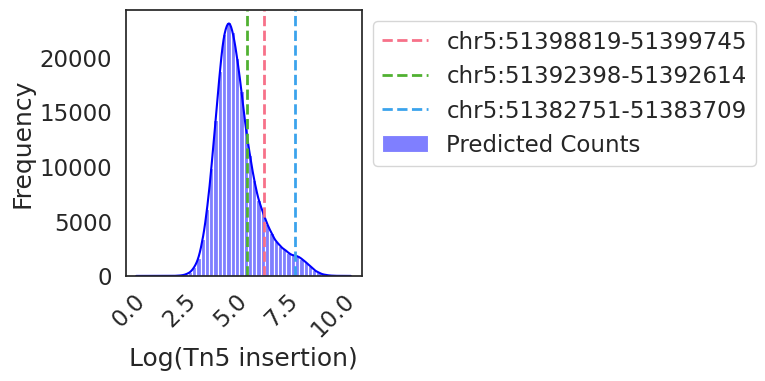

In [18]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks_selected["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot each ISL1 CRE as a vertical line each with a different color
    CRE_colors = sns.color_palette("husl", peaks_selected["CRE_annotation"].nunique())
    for i, (CRE_name, group) in enumerate(peaks_selected.groupby("CRE_annotation")):
        if CRE_name.startswith("CRE_"):
            CRE_color = CRE_colors[i % len(CRE_colors)]
            #Grab chr:start-end for label
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=CRE_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

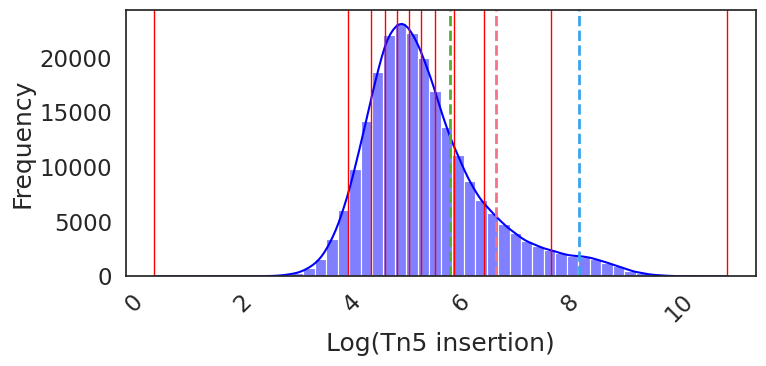

In [19]:
# Plot a beautiful histogram of the predictions with deciles
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks_selected["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot each ISL1 CRE as a vertical line each with a different color
    CRE_colors = sns.color_palette("husl", peaks_selected["CRE_annotation"].nunique())
    for i, (CRE_name, group) in enumerate(peaks_selected.groupby("CRE_annotation")):
        if CRE_name.startswith("CRE_"):
            CRE_color = CRE_colors[i % len(CRE_colors)]
            #Grab chr:start-end for label
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=CRE_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

    # Add vertical lines for deciles
    for decile in deciles:
        ax.axvline(decile, color='red', linestyle='-', linewidth=1)

    # Move legend outside of the plot
    #ax.legend(loc='lower center', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# CRE design

In [20]:
MPRA_integrated_sequence_1 = "gggtctctctggttagaccagatctgagcctgggagctctctggctaactagggaacccactgcttaagcctcaataaagcttgccttgagtgcttcaagtagtgtgtgcccgtctgttgtgtgactctggtaactagagatccctcagacccttttagtcagtgtggaaaatctctagcagtggcgcccgaacagggacttgaaagcgaaagggaaaccagaggagctctctcgacgcaggactcggcttgctgaagcgcgcacggcaagaggcgaggggcggcgactggtgagtacgccaaaaattttgactagcggaggctagaaggagagagatgggtgcgagagcgtcagtattaagcgggggagaattagatcgcgatgggaaaaaattcggttaaggccagggggaaagaaaaaatataaattaaaacatatagtatgggcaagcagggagctagaacgattcgcagttaatcctggcctgttagaaacatcagaaggctgtagacaaatactgggacagctacaaccatcccttcagacaggatcagaagaacttagatcattatataatacagtagcaaccctctattgtgtgcatcaaaggatagagataaaagacaccaaggaagctttagacaagatagaggaagagcaaaacaaaagtaagaccaccgcacagcaagcggccggccgctgatcttcagacctggaggaggagatatgagggacaattggagaagtgaattatataaatataaagtagtaaaaattgaaccattaggagtagcacccaccaaggcaaagagaagagtggtgcagagagaaaaaagagcagtgggaataggagctttgttccttgggttcttgggagcagcaggaagcactatgggcgcagcgtcaatgacgctgacggtacaggccagacaattattgtctggtatagtgcagcagcagaacaatttgctgagggctattgaggcgcaacagcatctgttgcaactcacagtctggggcatcaagcagctccaggcaagaatcctggctgtggaaagatacctaaaggatcaacagctcctggggatttggggttgctctggaaaactcatttgcaccactgctgtgccttggaatgctagttggagtaataaatctctggaacagatttggaatcacacgacctggatggagtgggacagagaaattaacaattacacaagcttaatacactccttaattgaagaatcgcaaaaccagcaagaaaagaatgaacaagaattattggaattagataaatgggcaagtttgtggaattggtttaacataacaaattggctgtggtatataaaattattcataatgatagtaggaggcttggtaggtttaagaatagtttttgctgtactttctatagtgaatagagttaggcagggatattcaccattatcgtttcagacccacctcccaaccccgaggggacccgacaggcccgaaggaatagaagaagaaggtggagagagagacagagacagatccattcgattagtgaacggatcggcactgcgtgcgccaattctgcagacaaatggcagtattcatccacaattttaaaagaaaaggggggattggggggtacagtgcaggggaaagaatagtagacataatagcaacagacatacaaactaaagaattacaaaaacaaattacaaaaattcaaaattttcgggtttattacagggacagcagagatccagtttggttagtaccgggcccggtgctttgctctgagccagcccaccagtttggaatgactcctttttatgacttgaattttcaagtataaagtctagtgctaaatttaatttgaacaactgtatagtttttgctggttgggggaaggaaaaaaaatggtggcagtgtttttttcagaattagaagtgaaatgaaaacttgttgtgtgtgaggatttctaatgacatgtggtggttgcatactgagtgaagccggtgagcattctgccatgtcaccccctcgtgctcagtaatgtactttacagaaatcctaaactcaaaagattgatataaaccatgcttcttgtgtatatccggtctcttctctgggtagtctcactcagcctgcatttctgccagggcccgctctagaccTGCAGGAGGACCGGATCAACTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNCATTGCGTGAACCGACACTAGAGGGTATATAATGGAAGCTCGACTTCCAGCTTGGCAATCCGGTACTGTGCAAAGTGAACACATCGCTAAGCGAAAGCTAAGNNNNNNNNNNNNNNNACCGGtcgccaccatggtgagcaagggcgaggagctgttcaccggggtggtgcccatcctggtcgagctggacggcgacgtaaacggccacaagttcagcgtgtccggcgagggcgagggcgatgccacctacggcaagctgaccctgaagttcatctgcaccaccggcaagctgcccgtgccctggcccaccctcgtgaccaccctgacctacggcgtgcagtgcttcagccgctaccccgaccacatgaagcagcacgacttcttcaagtccgccatgcccgaaggctacgtccaggagcgcaccatcttcttcaaggacgacggcaactacaagacccgcgccgaggtgaagttcgagggcgacaccctggtgaaccgcatcgagctgaagggcatcgacttcaaggaggacggcaacatcctggggcacaagctggagtacaactacaacagccacaacgtctatatcatggccgacaagcagaagaacggcatcaaggtgaacttcaagatccgccacaacatcgaggacggcagcgtgcagctcgccgaccactaccagcagaacacccccatcggcgacggccccgtgctgctgcccgacaaccactacctgagcacccagtccgccctgagcaaagaccccaacgagaagcgcgatcacatggtcctgctggagttcgtgaccgccgccgggatcactctcggcatggacgagctgtacaagtaggaattcgtcgagggacctaataacttcgtatagcatacattatacgaagttatacatgtttaagggttccggttccactaggtacaattcgatatcaagcttatcgataatcaacctctggattacaaaatttgtgaaagattgactggtattcttaactatgttgctccttttacgctatgtggatacgctgctttaatgcctttgtatcatgctattgcttcccgtatggctttcattttctcctccttgtataaatcctggttgctgtctctttatgaggagttgtggcccgttgtcaggcaacgtggcgtggtgtgcactgtgtttgctgacgcaacccccactggttggggcattgccaccacctgtcagctcctttccgggactttcgctttccccctccctattgccacggcggaactcatcgccgcctgccttgcccgctgctggacaggggctcggctgttgggcactgacaattccgtggtgttgtcggggaaatcatcgtcctttccttggctgctcgcctgtgttgccacctggattctgcgcgggacgtccttctgctacgtcccttcggccctcaatccagcggaccttccttcccgcggcctgctgccggctctgcggcctcttccgcgtcttcgccttcgccctcagacgagtcggatctccctttgggccgcctccccgcatcgataccgtcgacctcgatcgagacctagaaaaacatggagcaatcacaagtagcaatacagcagctaccaatgctgattgtgcctggctagaagcacaagaggaggaggaggtgggttttccagtcacacctcaggtaccaagcatggggtaaagtactgttctcatcacatcatatcaaggttatataccatcaatattgccacagatgttacttagccttttaatatttctctaatttagtgtatatgcaatgatagttctctgatttctgagattgagtttctcatgtgtaatgattatttagagtttctctttcatctgttcaaatttttgtctagttttattttttactgatttgtaagacttctttttataatctgcatattacaattctctttactggggtgttgcaaatattttctgtcattctatggcctgacttttcttaatggttttttaattttaaaaataagtcttaatattcatgcaatctaattaacaatcttttctttgtggttaggactttgagtcataagaaatttttctctacactgaagtcatgatggcatgcttctatattattttctaaaagatttaaagttttgccttctccatttagacttataattcactggaatttttttgtgtgtatggtatgacatatgggttcccttttattttttacatataaatatatttccctgtttttctaaaaaagaaaaagatcatcattttcccattgtaaaatgccatatttttttcataggtcacttacatatatcaatgggtctgtttctgagctctactctattttatcagcctcactgtctatccccacacatctcatgctttgctctaaatcttgatatttagtggaacattctttcccattttgttctacaagaatatttttgttattgtcttttgggcttctatatacattttagaatgaggttggcaagttctgtagatcttagccactttttaaaagaaaaggggggactggaagggctaattcactcccaacgaagacaagatatccttgatctgtggatctaccacacacaaggctacttccctgattggcagaactacacaccagggccagggatcagatatccactgacctttggatggtgctacaagctagtaccagttgagcaagagaaggtagaagaagccaatgaaggagagaacacccgcttgttacaccctgtgagcctgcatgggatggatgacccggagagagaagtattagagtggaggtttgacagccgcctagcatttcatcacatggcccgagagctgcatccggactgtactgggtctctctggttagaccagatctgagcctgggagctctctggctaactagggaacccactgcttaagcctcaataaagcttgccttgagtgcttcaagtagtgtgtgcccgtctgttgtgtgactctggtaactagagatccctcagacccttttagtcagtgtggaaaatctctagca"
len(MPRA_integrated_sequence_1), MPRA_integrated_sequence_1.count('N')

(5516, 285)

In [21]:
# Define model and ism params
seq_len = 2114
target_len = 1000
ism_window = 270
plot_window = 270

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - ism_window // 2
seq_end = seq_center + ism_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - ism_window // 2
target_end = target_center + ism_window // 2

# Plot starts
plot_seq_center = 1057
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

seq_start: 922, seq_end: 1192
target_start: 365, target_end: 635
plot_seq_start: 922, plot_seq_end: 1192
plot_target_start: 365, plot_target_end: 635


In [22]:
# Candidate
CRE_idx = 2

# Create run hash
run_hash = create_run_hash()

In [23]:
# Prep
design_res = {}
CRE_ = peaks_selected[peaks_selected["CRE_annotation"].notnull()].iloc[CRE_idx]
idx_ = peaks_selected[peaks_selected["CRE_annotation"].notnull()].index[CRE_idx]
chrom_ = CRE_["chrom"]
start_ = CRE_["start"]
end_ = CRE_["end"]
summit_ = CRE_["peak"]
decile_ = CRE_["decile"]
preds_ = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing CRE: {chrom_}:{start_}-{end_}: {preds_}")

plot_coordinate_start = start_ + summit_ - plot_window // 2
plot_coordinate_end = plot_coordinate_start + plot_window
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

# Params
dtype = torch.float64
k = 10
temp = 0.75
mode = "target"
delta = 0.1
max_iter = 15
n_runs = 100

Processing CRE: chr5:51392398-51392614: 5.7983985
Plotting coordinates: chr5:51392367-51392637


In [24]:
# Create directory to save
dir_name = f"ISL1_{chrom_}:{start_}-{end_}_ISM_design_{run_hash}"
os.makedirs(os.path.join(path_out, dir_name), exist_ok=True)

## Reference prediction

In [25]:
# Verify prediction
ref_seq_start = start_ + summit_ - seq_len // 2
ref_seq_end = ref_seq_start + seq_len
design_res["reference_locus"] = f"{chrom_}:{ref_seq_start}-{ref_seq_end}"
ref_seq = genome[chrom_][ref_seq_start:ref_seq_end].seq.upper()
design_res["reference_sequence"] = ref_seq
X_ref = torch.tensor(sp.ohe([ref_seq], alphabet=sp.DNA).transpose(0, 2, 1), dtype=torch.uint8)
y_ref = predict(
    model=count_wrapper.type(torch.float32),
    X=X_ref,
    verbose=True,   
)
design_res["reference_prediction"] = y_ref.item()
design_res

100%|██████████| 1/1 [00:00<00:00,  3.39it/s]


{'reference_locus': 'chr5:51391445-51393559',
 'reference_sequence': 'GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTCTGGTTTAACTGTCACACATTGAAAGATTCAGTGGGGAGGGTGCCTTCTTGGGCTCAGGGTTGGGGAGAAACCAAGGAGGTGGGTAATGAAGAGAAGGGAGACAAATGCAGGGAAAACGAACCTCTTGGCATCTTTTTTTTTTTAATGAGACTGCATAATTTGACCATATAGGTTGAATTTTCTATCAATCAGGCCTTCTTTGAAGGATTAATTTCAAGGTACCTAACTCTAGGTAGCATGTGCCAGAAGATGTACAGTGTTGGAGAATCATACATCTTAGAATTTTAGAGTTGTCAAGGACTTCAGGAAATCGTCTTGGCATTTCAATCAGCAATTAGTAAGTTTATCCTTCCTGAGCATCTAGAGAATGGGATATATAGGACCCAAATCAAGGCGATTGTAGTATATAATCAATGCTATAATACACAATCAGTGTTGTTATCAATAAACAGCAGGCATGTGTCTGGGTACAATTTTCAAATATATTAATAAAGATTATTCAAATAGATGAATACTTTTTGTTACAGTATCCCTTGCTGGGAATGTCTTAATCTAAAATGTAGGACCGTTTAAATGTTTTCAAGTGTATGAGTTCAAATGTCATAGAGACACACAGTGTGTACCATGTATAGCAAAAGGGACATGAGCTCTACCAATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGA

## Baseline prediction

In [26]:
# Get barcode and insert sequence
insert_len = 270
insert_seq_start = start_ + summit_ - insert_len // 2
insert_seq_end = start_ + summit_ + insert_len // 2
insert_seq = genome[chrom_][insert_seq_start:insert_seq_end].seq
barcode_seq = ''.join(random.choices('ACGT', k=15))
print(f"Length of insert sequence: {len(insert_seq)}")
print(f"Length of barcode sequence: {len(barcode_seq)}")

# Find the start and end of the 270 'N's in a row
insert_start = MPRA_integrated_sequence_1.find('N' * 270)
insert_end = insert_start + 270
print(f"Insert sequence will be placed at: {insert_start} to {insert_end} in the MPRA integrated sequence.")
MPRA_seq = MPRA_integrated_sequence_1[:insert_start] + insert_seq + MPRA_integrated_sequence_1[insert_end:]
print(f"Number of 'N's in the MPRA sequence: {MPRA_seq.count('N')}")

# Find the start and end of exactly 15 'N's in a row and no more than 15 N's
barcode_start = MPRA_seq.find('N' * 15)
barcode_end = barcode_start + 15
print(f"Barcode sequence will be placed at: {barcode_start} to {barcode_end} in the MPRA integrated sequence.")
MPRA_seq = MPRA_seq[:barcode_start] + barcode_seq + MPRA_seq[barcode_end:]
print(f"Number of 'N's in the MPRA sequence: {MPRA_seq.count('N')}")

# Create seq by inserting insert_seq and barcode_seq into MPRA_integrated_sequence_1 at proper positions
MPRA_seq = MPRA_seq.upper()
print(f"Final MPRA sequence length: {len(MPRA_seq)}")

Length of insert sequence: 270
Length of barcode sequence: 15
Insert sequence will be placed at: 2190 to 2460 in the MPRA integrated sequence.
Number of 'N's in the MPRA sequence: 15
Barcode sequence will be placed at: 2562 to 2577 in the MPRA integrated sequence.
Number of 'N's in the MPRA sequence: 0
Final MPRA sequence length: 5516


In [27]:
# Need to get seq_len from MPRA seq around insert center
insert_center = insert_start + 270 // 2
baseline_seq_start = insert_center - seq_len // 2
baseline_seq_end = insert_center + seq_len // 2
baseline_seq = MPRA_seq[baseline_seq_start:baseline_seq_end]
design_res["baseline_sequence"] = baseline_seq
X_baseline = torch.tensor(sp.ohe([baseline_seq], alphabet=sp.DNA).transpose(0, 2, 1), dtype=torch.uint8)
y_baseline = predict(
    model=count_wrapper.type(torch.float32),
    X=X_baseline,
    verbose=True,
)
design_res["baseline_prediction"] = y_baseline.item()
design_res

100%|██████████| 1/1 [00:00<00:00, 345.61it/s]


{'reference_locus': 'chr5:51391445-51393559',
 'reference_sequence': 'GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTCTGGTTTAACTGTCACACATTGAAAGATTCAGTGGGGAGGGTGCCTTCTTGGGCTCAGGGTTGGGGAGAAACCAAGGAGGTGGGTAATGAAGAGAAGGGAGACAAATGCAGGGAAAACGAACCTCTTGGCATCTTTTTTTTTTTAATGAGACTGCATAATTTGACCATATAGGTTGAATTTTCTATCAATCAGGCCTTCTTTGAAGGATTAATTTCAAGGTACCTAACTCTAGGTAGCATGTGCCAGAAGATGTACAGTGTTGGAGAATCATACATCTTAGAATTTTAGAGTTGTCAAGGACTTCAGGAAATCGTCTTGGCATTTCAATCAGCAATTAGTAAGTTTATCCTTCCTGAGCATCTAGAGAATGGGATATATAGGACCCAAATCAAGGCGATTGTAGTATATAATCAATGCTATAATACACAATCAGTGTTGTTATCAATAAACAGCAGGCATGTGTCTGGGTACAATTTTCAAATATATTAATAAAGATTATTCAAATAGATGAATACTTTTTGTTACAGTATCCCTTGCTGGGAATGTCTTAATCTAAAATGTAGGACCGTTTAAATGTTTTCAAGTGTATGAGTTCAAATGTCATAGAGACACACAGTGTGTACCATGTATAGCAAAAGGGACATGAGCTCTACCAATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGA

## ISM design

In [28]:
# imports
import numpy as np
from tangermeme.predict import predict
from tangermeme.ism import saturation_mutagenesis


def greedy_ism(
    model,
    X,
    seq_len=2114,
    ism_window=500,
    k=1,
    temp=1.0,
    max_iter=10,
    verbose=False,
    mode="maximize",
    y_bar=None,
    delta=None,
    random_state=None
):
    """
    Perform greedy ISM on a sequence.

    Parameters
    ----------
    model : BPNet
        The model to use for prediction.
    X : torch.Tensor
        The input sequence as a one-hot encoded tensor.
    seq_len : int
        The length of the input sequence.
    ism_window : int
        The window size for ISM.
    k : int
        The number of top positions to select.
    max_iter : int
        The maximum number of iterations to perform.
    verbose : bool
        Whether to print progress messages.
    mode : str
        Whether to 'maximize' or 'minimize' the model score. Default is 'maximize'.

    Returns
    -------
    X_ : torch.Tensor
        The modified sequence after greedy ISM.
    """

    # Set up random number generator if random_state is not None
    if random_state is not None:
        if isinstance(random_state, int):
            rng = np.random.default_rng(random_state)
        elif isinstance(random_state, np.random.Generator):
            rng = random_state
    else:
        rng = np.random.default_rng()

    # Define seq limits
    seq_center = seq_len // 2
    seq_start = seq_center - ism_window // 2
    seq_end = seq_center + ism_window // 2

    # Initial copy of the tensor
    X_ = X.clone()

    # Get the original prediction
    y0 = predict(model, X_).cpu().numpy()[0]
    if verbose:
        print(f"Iteration 0/{max_iter} - y_hat: {y0[0]:.3f}")

    # Run ISM across rounds
    for i in range(max_iter):
        if verbose:
            print(f"Iteration {i+1}/{max_iter}", end="")

        # Run ISM
        y0, y_hat = saturation_mutagenesis(
            model,
            X_,
            start=seq_start,
            end=seq_end,
            raw_outputs=True,
            verbose=False,
        )

        # Get the updates
        if mode in ["maximize", "minimize"]:
            attr = y_hat[:, :, :, 0] - y0[:, None, None, 0]
        elif mode == "target":
            if y_bar is None:
                raise ValueError("y_bar must be specified when mode is 'target'")
            attr = -torch.abs(y_hat[:, :, :, 0] - y_bar)
        attr = attr.numpy()

        # Take the average across the batch
        if X.shape[0] == 2:
            attr_mean = np.mean(attr, axis=0)
        else:
            attr_mean = attr.squeeze(0)

        # Flip attribution if minimizing
        if mode == "minimize":
            attr_mean = -attr_mean

        # Get the top k positions
        idx = np.argsort(attr_mean.ravel())[:-k-1:-1]
        
        # if k==1, select the first
        if k == 1:
            indices = np.column_stack(np.unravel_index(idx, attr_mean.shape))[0]

        # if k>1, randomly select one of the indices, using temperature
        elif k > 1:
            idxs = np.column_stack(np.unravel_index(idx, attr_mean.shape))
            predictions = attr_mean[idxs[:, 0], idxs[:, 1]]
            probs = np.exp(predictions / temp)
            probs /= probs.sum()
            indices = rng.choice(np.column_stack(np.unravel_index(idx, attr_mean.shape)), size=1, p=probs)[0]

        # if k<1, raise an error
        else:
            raise ValueError("k must be greater than or equal to 1")

        # if verbose print out the new y_hat value
        if verbose:
            y_hat_np = y_hat[:, :, :, 0].cpu().numpy()
            print(f" - y_hat: {y_hat_np[0, indices[0], indices[1]]:.3f}")

        # Get the edit channel and position
        edit_channel = indices[0]
        edit_position = seq_start + indices[1]

        # zero out the position across the channels
        X_[0, :, edit_position] = 0
        X_[0, edit_channel, edit_position] = 1

        if mode == "target":
            if delta is not None:
                # Check to see if we are in delta of target, break if so
                curr_delta = np.abs(attr_mean[indices[0], indices[1]])
                if curr_delta < delta:
                    print(f"Breaking early at iteration {i+1}/{max_iter} - curr_delta: {curr_delta:.3f}")
                    break

    return X_

In [29]:
# Get a list of all deciles above _decile_
deciles_above = deciles[int(decile_)+1:]
print(f"Deciles above {decile_}: {deciles_above}")

y_bars = [torch.zeros(1, dtype=torch.float32) + d for d in deciles_above]
y_bars

Deciles above 7.0: [ 5.86997775  6.41905241  7.63897895 10.879662  ]


[tensor([5.8700]), tensor([6.4191]), tensor([7.6390]), tensor([10.8797])]

In [30]:
X_hat = []
for y_bar in tqdm(y_bars, desc="Running ISM for each decile"):
    print(f"Running ISM for decile target: {y_bar.item()}")
    X_hat_ = []
    for i in tqdm(range(n_runs)):
        X_hat_.append(greedy_ism(
            count_wrapper,
            X_baseline,
            seq_len=seq_len,
            ism_window=ism_window,
            k=k,
            temp=temp,
            mode="target",
            y_bar=y_bar,
            delta=delta,
            max_iter=max_iter,
            verbose=False
        ))
    X_hat.append(X_hat_)
X_hat = [torch.stack(x_hat_) for x_hat_ in X_hat]
X_hat = torch.stack(X_hat)
X_hat.shape

Running ISM for each decile:   0%|          | 0/4 [00:00<?, ?it/s]

Running ISM for decile target: 5.869977951049805


  0%|          | 0/100 [00:00<?, ?it/s]

Breaking early at iteration 1/15 - curr_delta: 0.085
Breaking early at iteration 2/15 - curr_delta: 0.000
Breaking early at iteration 2/15 - curr_delta: 0.004
Breaking early at iteration 1/15 - curr_delta: 0.095
Breaking early at iteration 1/15 - curr_delta: 0.079
Breaking early at iteration 1/15 - curr_delta: 0.079
Breaking early at iteration 2/15 - curr_delta: 0.006
Breaking early at iteration 2/15 - curr_delta: 0.004
Breaking early at iteration 2/15 - curr_delta: 0.005
Breaking early at iteration 2/15 - curr_delta: 0.000
Breaking early at iteration 1/15 - curr_delta: 0.079
Breaking early at iteration 1/15 - curr_delta: 0.085
Breaking early at iteration 1/15 - curr_delta: 0.079
Breaking early at iteration 2/15 - curr_delta: 0.000
Breaking early at iteration 1/15 - curr_delta: 0.095
Breaking early at iteration 1/15 - curr_delta: 0.098
Breaking early at iteration 1/15 - curr_delta: 0.085
Breaking early at iteration 2/15 - curr_delta: 0.002
Breaking early at iteration 2/15 - curr_delta:

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Breaking early at iteration 6/15 - curr_delta: 0.000
Breaking early at iteration 5/15 - curr_delta: 0.002
Breaking early at iteration 6/15 - curr_delta: 0.087
Breaking early at iteration 6/15 - curr_delta: 0.003
Breaking early at iteration 6/15 - curr_delta: 0.004
Breaking early at iteration 6/15 - curr_delta: 0.026
Breaking early at iteration 5/15 - curr_delta: 0.060
Breaking early at iteration 6/15 - curr_delta: 0.006
Breaking early at iteration 6/15 - curr_delta: 0.003
Breaking early at iteration 6/15 - curr_delta: 0.006
Breaking early at iteration 6/15 - curr_delta: 0.002
Breaking early at iteration 6/15 - curr_delta: 0.011
Breaking early at iteration 5/15 - curr_delta: 0.004
Breaking early at iteration 6/15 - curr_delta: 0.003
Breaking early at iteration 6/15 - curr_delta: 0.001
Breaking early at iteration 5/15 - curr_delta: 0.053
Breaking early at iteration 6/15 - curr_delta: 0.007
Breaking early at iteration 6/15 - curr_delta: 0.001
Breaking early at iteration 6/15 - curr_delta:

  0%|          | 0/100 [00:00<?, ?it/s]

Breaking early at iteration 15/15 - curr_delta: 0.000


torch.Size([4, 100, 1, 4, 2114])

In [31]:
# Create identifiers for each of X_hat based on ISL1_{chrom_}:{start_}-{end_}_ISM_run_{run}_decile_{decile}
identifiers = []
for decile in range(X_hat.shape[0]):
    for run in range(X_hat.shape[1]):
        for t, seq in enumerate(range(X_hat.shape[2])):
            identifiers.append(f"ISL1_{chrom_}:{start_}-{end_}_ISM_run-{run+1}_target-{round(y_bars[decile].item(), 2)}_{t+1}")

In [32]:
# Stack the everything but the last two dims
X_optim = X_hat.view(-1, X_hat.shape[-2], X_hat.shape[-1])
X_optim.shape

torch.Size([400, 4, 2114])

100%|██████████| 4/4 [00:00<00:00, 13.60it/s]


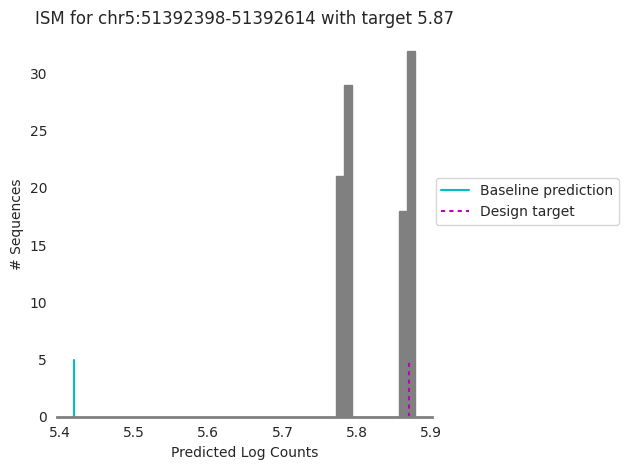

100%|██████████| 4/4 [00:00<00:00, 40.34it/s]


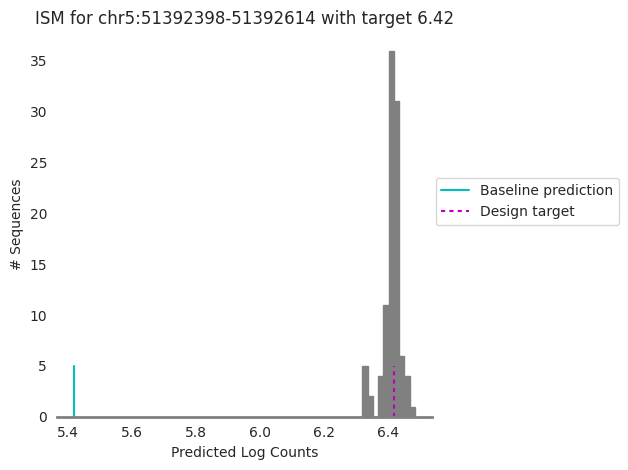

100%|██████████| 4/4 [00:00<00:00, 40.45it/s]


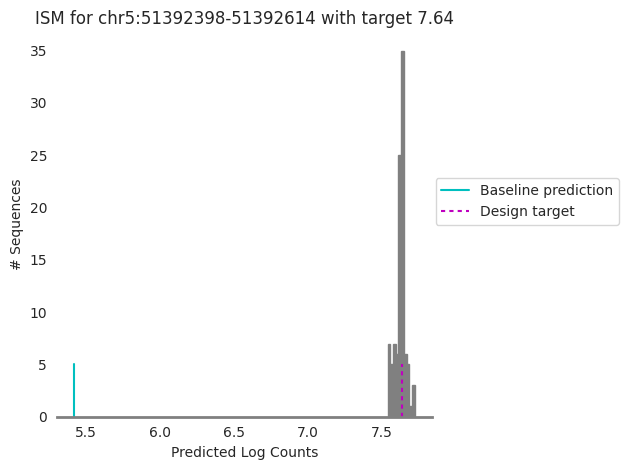

100%|██████████| 4/4 [00:00<00:00, 38.62it/s]


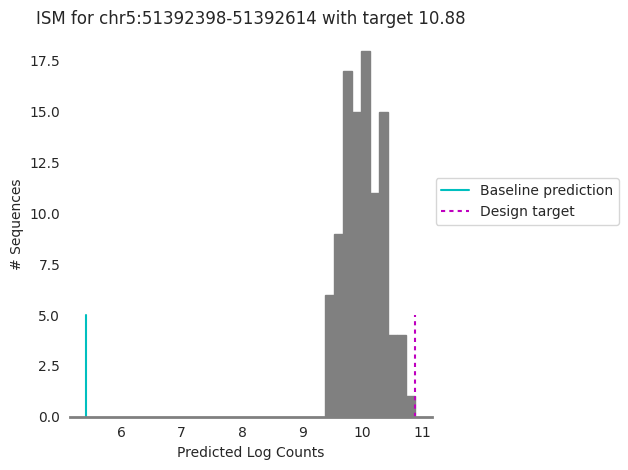

In [33]:
y_hat = []
for j, y_bar in enumerate(y_bars):
    y0 = y_baseline.numpy(force=True)[0, 0]
    batch_size = n_runs
    X_hat = X_optim[j*batch_size:(j+1)*batch_size]
    ax = plt.subplot(111)
    y_hat_ = predict(
        model=count_wrapper.type(torch.float32),
        X=X_hat,
        verbose=True,
    )
    plt.hist(y_hat_, facecolor='0.5', edgecolor='0.5')
    y_hat.append(y_hat_)
    plt.plot([y0, y0], [0, 5], label="Baseline prediction", c='c')
    plt.plot([y_bar, y_bar], [0, 5], label="Design target", c='m', linestyle=(0, (2, 2)))
    plt.title(f"ISM for {chrom_}:{start_}-{end_} with target {round(y_bar.item(), 2)}")
    plt.legend(loc=(1.01, 0.5))
    plt.xlabel("Predicted Log Counts")
    plt.ylabel("# Sequences")
    sns.despine(left=True)
    plt.grid(False)
    plt.setp(ax.spines.values(), linewidth=2, color='0.5')
    plt.tight_layout()
    plt.savefig(os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_design_target_{round(y_bar.item(), 2)}_{run_hash}.pdf"), dpi=300)
    plt.show()
y_hat = torch.stack(y_hat).squeeze()
y_hat = y_hat.view(-1)

## Save results

In [34]:
optim_seqs = sp.decode_ohe(X_optim.detach().cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
optim_seqs = [b''.join(optim_seq).decode('utf-8') for optim_seq in optim_seqs]
optim_seqs[:5]

['AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTGGAATTGGTTTAACATAACAAATTGGCTGTGGTATATAAAATTATTCATAATGATAGTAGGAGGCTTGGTAGGTTTAAGAATAGTTTTTGCTGTACTTTCTATAGTGAATAGAGTTAGGCAGGGATATTCACCATTATCGTTTCAGACCCACCTCCCAACCCCGAGGGGACCCGACAGGCCCGAAGGAATAGAAGAAGAAGGTGGAGAGAGAGACAGAGACAGATCCATTCGATTAGTGAACGGATCGGCACTGCGTGCGCCAATTCTGCAGACAAATGGCAGTATTCATCCACAATTTTAAAAGAAAAGGGGGGATTGGGGGGTACAGTGCAGGGGAAAGAATAGTAGACATAATAGCAACAGACATACAAACTAAAGAATTACAAAAACAAATTACAAAAATTCAAAATTTTCGGGTTTATTACAGGGACAGCAGAGATCCAGTTTGGTTAGTACCGGGCCCGGTGCTTTGCTCTGAGCCAGCCCACCAGTTTGGAATGACTCCTTTTTATGACTTGAATTTTCAAGTATAAAGTCTAGTGCTAAATTTAATTTGAACAACTGTATAGTTTTTGCTGGTTGGGGGAAGGAAAAAAAATGGTGGCAGTGTTTTTTTCAGAATTAGAAGTGAAATGAAAACTTGTTGTGTGTGAGGATTTCTAATGACATGTGGTGGTTGCATACTGAGTGAAGCCGGTGAGCATTCTGCCATGTCACCCCCTCGTGCTCAGTAATGTACTTTACAGAAATCCTAAACTCAAAAGATTGATATAAACCATGCTTCTTGTGTATATCCGGTCTCTTCTCTGGGTAGTCTCACTCAGCCTGCATTTCTGCCAGGGCCCGCTCTAGACCTGCAGGAGGACCGGATCAACTTATCCTGAAACCTTGTTCCCTTTTTCGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATATTTACCTGG

In [35]:
# Create a dataframe with the following specs
# Column name	Example	Description
# id	ISL1_chr5:51382751-51383709_ISM_run-1_target-10.88	Designed sequence identifier of form ISL1_{peak_chromosome}:{peak_start_coordinate}-{peak_end_coordinate}_{method}_run-{run}_target-{target}
# reference_locus	chr5:51382751-51383709	BED coordinates for the peak that was used to generate the designed sequence
# reference_sequence	TCAACC…	Reference genome sequence centered on the summit of reference_locus peak. Length corresponds to model input length
# reference_prediction	8.27	Prediction from model on reference_sequence
# baseline_sequence	ACCAAC…	MPRA integrated sequence with genomic insert
# baseline_prediction	8.39	Prediction from model on baseline_sequence
# design_method	Ledidi	Method used to design sequence
# design_sequence	ACGAA…	MPRA integrated sequence with designed insert
# design_target_prediction	10.88	Target prediction for design process
# design_prediction	10.15	Prediction from model on design_sequence
design_df = pd.DataFrame({
    "id": identifiers,
    "reference_locus": design_res["reference_locus"],
    "reference_sequence": design_res["reference_sequence"],
    "reference_prediction": design_res["reference_prediction"],
    "baseline_sequence": design_res["baseline_sequence"],
    "baseline_prediction": design_res["baseline_prediction"],
    "design_method": "Ledidi",
    "design_sequence": optim_seqs,
    "design_target_prediction": np.concatenate([np.repeat(y_bar.item(), n_runs) for y_bar in y_bars]),
    "design_prediction": y_hat.numpy(force=True),
})
design_df.head()

,id,reference_locus,reference_sequence,reference_prediction,baseline_sequence,baseline_prediction,design_method,design_sequence,design_target_prediction,design_prediction
0,ISL1_chr5:51392398-51392614_ISM_run-1_target-5...,chr5:51391445-51393559,GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTC...,5.787425,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.419341,Ledidi,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.869978,5.785137
1,ISL1_chr5:51392398-51392614_ISM_run-2_target-5...,chr5:51391445-51393559,GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTC...,5.787425,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.419341,Ledidi,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.869978,5.869948
2,ISL1_chr5:51392398-51392614_ISM_run-3_target-5...,chr5:51391445-51393559,GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTC...,5.787425,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.419341,Ledidi,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.869978,5.865590
3,ISL1_chr5:51392398-51392614_ISM_run-4_target-5...,chr5:51391445-51393559,GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTC...,5.787425,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.419341,Ledidi,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.869978,5.774633
4,ISL1_chr5:51392398-51392614_ISM_run-5_target-5...,chr5:51391445-51393559,GTGTCAGCTCCCAGATGGAAGAGGCTGAATTCCCAACAGGAGACTC...,5.787425,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.419341,Ledidi,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,5.869978,5.791346


In [36]:
# Save dataframe to tsv
# Also add design parameters as a header, # method: Ledidi, n_runs: 2, n_seqs: 10, prune: True, prune_threshold: 0.5, etc
header = {
    "method": "ISM",
    "n_runs": n_runs,
    "k": k,
    "temp": temp,
    "mode": mode,
    "delta": delta,
    "max_iter": max_iter,
    "n_runs": n_runs,
    "run_hash": run_hash
}
with open(os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_design_{run_hash}.tsv"), 'w', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    for key, value in header.items():
        writer.writerow([f"# {key}: {value}"])
    design_df.to_csv(f, sep="\t", index=False, float_format='%.4f')

In [37]:
# Save X_optim to npz
np.savez_compressed(os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_X_optim_{run_hash}.npz"), X_optim=X_optim.numpy(force=True))

## Attributions

In [38]:
# Get attribution scores for the original sequence
X_baseline_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_baseline.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_baseline_attr_.shape

100%|██████████| 20/20 [00:29<00:00,  1.46s/it]


torch.Size([1, 4, 2114])

In [39]:
# Get attribution scores for the original sequence
X_optim_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_optim.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_optim_attr_.shape

100%|██████████| 8000/8000 [04:55<00:00, 27.08it/s]


torch.Size([400, 4, 2114])

In [40]:
# Save attribution scores to npz
np.savez_compressed(os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_X_baseline_attr_{run_hash}.npz"), X_baseline_attr=X_baseline_attr_.numpy(force=True))
np.savez_compressed(os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_X_optim_attr_{run_hash}.npz"), X_optim_attr=X_optim_attr_.numpy(force=True))

## Quantify edits

In [41]:
# Want the following long data frame to quantify the differences
# Column name	Example	Description
# id	ISL1_chr5:51382751-51383709_Ledidi_run-1_target-10.88	Designed sequence identifier of form ISL1_{peak_chromosome}:{peak_start_coordinate}-{peak_end_coordinate}_{method}_run-{run}_target-{target}
# pos	1069	Position from start of input sequence where the edit occurs
# ref	C	Nucleotide in the baseline_sequence corresponding to this id
# alt	G	Nucleotide in the design_sequence corresponding to this id

# Diffs is a list of lists of tuples and we need to match up each list with id
diffs = []
for j in range(len(optim_seqs)):
    diffs_ = [(i, baseline_seq[i], optim_seqs[j][i]) for i in range(len(baseline_seq)) if baseline_seq[i] != optim_seqs[j][i]]
    diffs.append(diffs_)

# Make df
edit_df = []
for i, diff_list in enumerate(diffs):
    id_ = identifiers[i]
    for pos, ref, alt in diff_list:
        edit_df.append({
            'id': id_,
            'pos': pos,
            'ref': ref,
            'alt': alt
        })
edit_df = pd.DataFrame(edit_df)
edit_df["id"].value_counts()

ISL1_chr5:51392398-51392614_ISM_run-100_target-10.88_1    15
ISL1_chr5:51392398-51392614_ISM_run-53_target-10.88_1     15
ISL1_chr5:51392398-51392614_ISM_run-29_target-10.88_1     15
ISL1_chr5:51392398-51392614_ISM_run-30_target-10.88_1     15
ISL1_chr5:51392398-51392614_ISM_run-31_target-10.88_1     15
                                                          ..
ISL1_chr5:51392398-51392614_ISM_run-45_target-5.87_1       1
ISL1_chr5:51392398-51392614_ISM_run-91_target-5.87_1       1
ISL1_chr5:51392398-51392614_ISM_run-41_target-5.87_1       1
ISL1_chr5:51392398-51392614_ISM_run-93_target-5.87_1       1
ISL1_chr5:51392398-51392614_ISM_run-1_target-5.87_1        1
Name: id, Length: 400, dtype: int64

In [42]:
# Save edit_df
edit_df.to_csv(os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_edits_{run_hash}.tsv"), sep="\t", index=False)

## Seqlets

In [43]:
# Call and annotate seqlets
optim_seqlets = recursive_seqlets(X_optim_attr_[:, :, seq_start:seq_end].sum(dim=1).detach(), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_optim[:, :, seq_start:seq_end].detach().cpu(), optim_seqlets, path_motifs)[0][:, 0]
optim_seqlets['start'] += seq_start
optim_seqlets['end'] += seq_start
motifs_ = motif_id_mp.loc[motif_names[motif_idxs]]
optim_seqlets["annotation"] = motifs_.values
optim_seqlets["id"] = [identifiers[idx] for idx in optim_seqlets["example_idx"]]
optim_seqlets.head()

,example_idx,start,end,attribution,p-value,annotation,id
0,170,938,960,-0.236711,0.000100,ETV6_MOUSE.H11MO.0.C,ISL1_chr5:51392398-51392614_ISM_run-71_target-...
1,201,938,957,-0.219178,0.000102,ETV6_MOUSE.H11MO.0.C,ISL1_chr5:51392398-51392614_ISM_run-2_target-7...
2,364,1013,1031,1.464495,0.000151,MAFB_HUMAN.H11MO.0.B,ISL1_chr5:51392398-51392614_ISM_run-65_target-...
3,266,970,985,0.022531,0.000175,TAL1_HUMAN.H11MO.0.A,ISL1_chr5:51392398-51392614_ISM_run-67_target-...
4,174,938,957,-0.208696,0.000276,ETV6_MOUSE.H11MO.0.C,ISL1_chr5:51392398-51392614_ISM_run-75_target-...


In [44]:
# Save
optim_seqlets[["id", "start", "end", "attribution", "p-value", "annotation"]].sort_values(["id", "start"]).to_csv(
    os.path.join(path_out, dir_name, f"ISL1_{chrom_}:{start_}-{end_}_ISM_seqlets_{run_hash}.tsv"), 
    sep="\t", 
    index=False
)

## Check one

In [49]:
seq_num = np.random.randint(0, len(optim_seqs))
print(f"Selected sequence number: {seq_num}")

Selected sequence number: 205


In [50]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_baseline.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(np.expand_dims(X_optim[seq_num].detach().cpu().numpy().astype(np.uint8), axis=0), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs, len(diffs)

([(945, 'T', 'A'),
  (947, 'T', 'C'),
  (976, 'T', 'A'),
  (977, 'T', 'A'),
  (1011, 'T', 'A'),
  (1037, 'G', 'A')],
 6)

In [51]:
# 
original_profile, original_counts = predict(model, X_baseline)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_optim[seq_num:seq_num+1])
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 225.75166412672493
mutated counts: 2130.5220374253536


((1000,), (1000,))

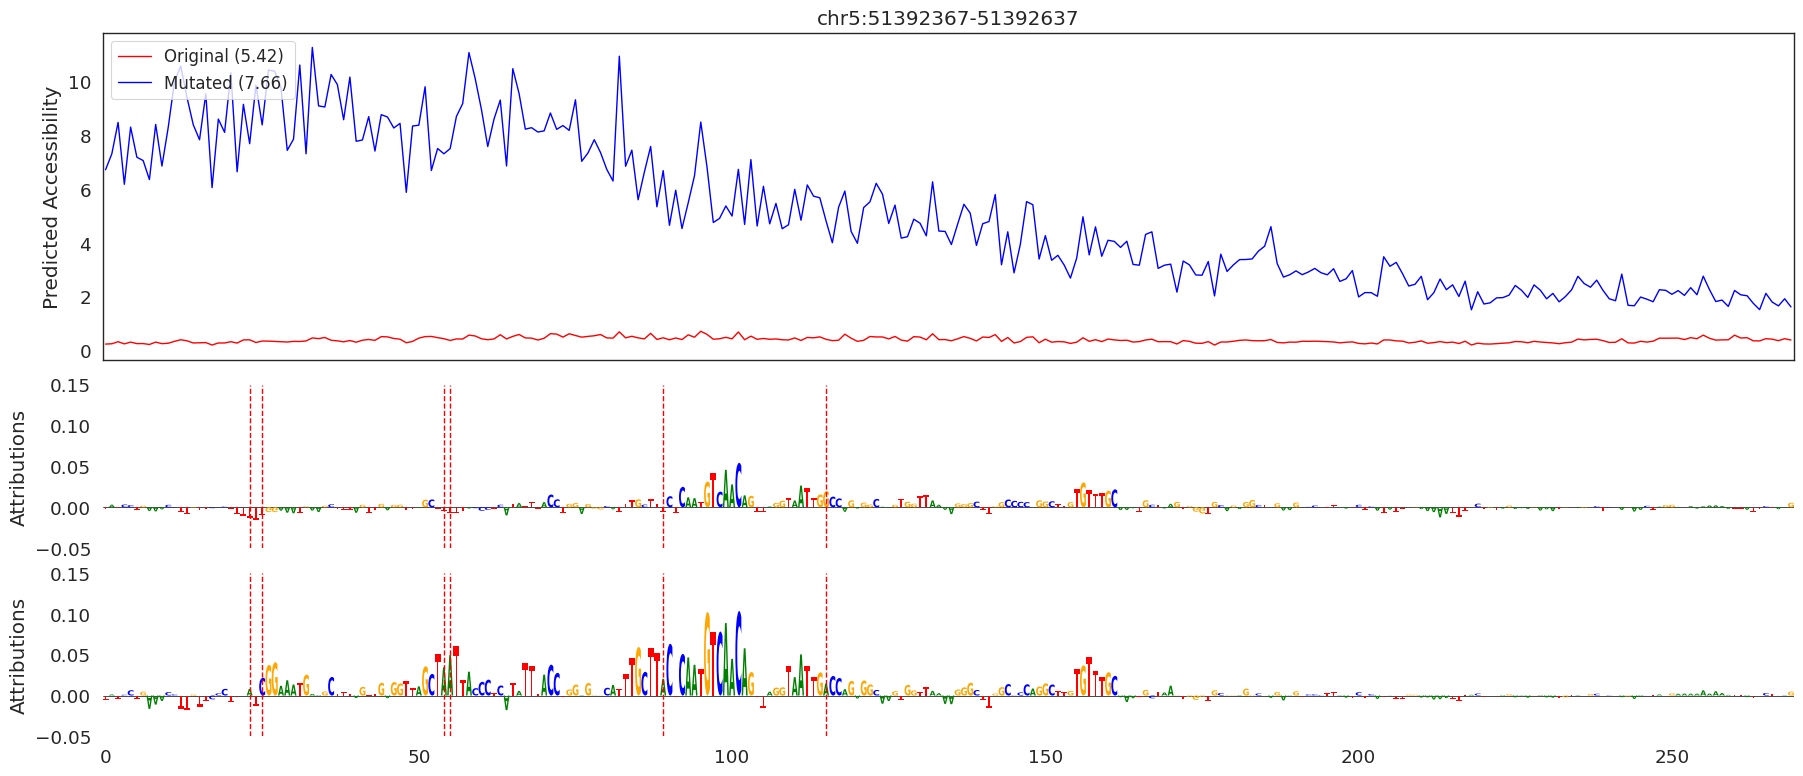

In [52]:
offset = 0

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_baseline_attr_[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_optim_attr_[seq_num].detach().cpu(), ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset)#, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

# DONE!

---